# Trabajo Práctico N.° 2 — Análisis de Series Temporales

## 09 — Modelos híbridos: Prophet y NeuralProphet

**Objetivo de este notebook:** cubrir la categoría "Modelos Híbridos (Prophet, Neural Prophet)" del punto 2 de la consigna del TP2. Ambos modelos descomponen la serie en tendencia + estacionalidad(es) + efectos adicionales, pero Prophet la ajusta con un modelo aditivo generalizado (GAM) mientras que NeuralProphet reemplaza esa estimación por una red neuronal, permitiendo además autorregresión explícita (`n_lags`).

**Nota de compatibilidad:** NeuralProphet 0.8.0 todavía usa internamente el alias `np.NaN`, eliminado en NumPy 2.0; se aplica un parche de una línea antes de importarlo. También se fija `learning_rate` explícitamente para evitar el buscador automático de tasa de aprendizaje, que falla con versiones recientes de PyTorch (ver `feedback_dl_libs_compat` en la memoria del proyecto).

**Dataset:** se usa `serie_california_tratada.csv` (salida de `07b_tratamiento_datos.ipynb`).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

import json
from pathlib import Path

import numpy as np
if not hasattr(np, "NaN"):
    np.NaN = np.nan  # neuralprophet 0.8.0 usa el alias que numpy 2.0 eliminó

import pandas as pd
import matplotlib.pyplot as plt

# Prophet necesita CmdStan compilado (ver feedback_dl_libs_compat en la memoria
# del proyecto). Resolver la ruta explícitamente ANTES de importar prophet
# evita una falla intermitente observada en Windows
# (AttributeError: 'Prophet' object has no attribute 'stan_backend').
import cmdstanpy
cmdstanpy.set_cmdstan_path(cmdstanpy.cmdstan_path())

from prophet import Prophet
from neuralprophet import NeuralProphet, set_log_level
from sklearn.metrics import mean_absolute_error, mean_squared_error

set_log_level("ERROR")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california_tratada.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
datos.index = datos.index.tz_localize(None)  # Prophet/NeuralProphet no admiten índice con timezone

HORAS_TEST = 24 * 7
VENTANA_DIAS = 365
print(f"Filas: {len(datos):,} | Ventana de entrenamiento: {VENTANA_DIAS} días | Holdout: {HORAS_TEST} horas")

Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


Filas: 242,402 | Ventana de entrenamiento: 365 días | Holdout: 168 horas


## 1. Prophet

Se entrena con estacionalidad diaria activada (`daily_seasonality=True`, el ciclo dominante de nuestras series horarias) y semanal activada por defecto; no se agregan feriados ni regresores externos por ahora.

**Nota sobre una falla de entorno (no de código):** el backend de Stan que usa Prophet falla de forma intermitente en Windows (`AttributeError: 'Prophet' object has no attribute 'stan_backend'`). Se investigó a fondo: no depende de los datos ni de la configuración del modelo — el mismo código exacto a veces funciona y a veces no, incluso reintentando dentro del mismo proceso. Es consistente con una carrera de recursos del sistema operativo al lanzar el subproceso compilado de Stan (posible interferencia de Windows Defender escaneando el ejecutable). Como no se encontró una forma 100% determinística de evitarlo, esta sección reintenta varias veces y, si Prophet sigue sin poder inicializarse, **continúa el notebook sin Prophet** para esa serie en vez de abortar todo — NeuralProphet (sección siguiente) cubre la misma categoría de la consigna de forma confiable.

In [2]:
def ajustar_prophet_con_reintento(train, intentos=5, **kwargs):
    ultimo_error = None
    for intento in range(1, intentos + 1):
        try:
            modelo = Prophet(**kwargs)
            modelo.fit(train)
            return modelo
        except AttributeError as exc:
            ultimo_error = exc
    print(f"  Prophet no pudo inicializarse tras {intentos} intentos (falla de entorno en Windows, ver nota arriba): {ultimo_error}")
    return None


resultados_prophet = {}

for col in datos.columns:
    serie = datos[col].iloc[-(VENTANA_DIAS * 24):]
    df = pd.DataFrame({"ds": serie.index, "y": serie.values})
    train, test = df.iloc[:-HORAS_TEST], df.iloc[-HORAS_TEST:]

    modelo = ajustar_prophet_con_reintento(
        train, daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False
    )
    if modelo is None:
        print(f"[Prophet - {col}] SALTEADO (falla de entorno)")
        continue

    futuro = modelo.make_future_dataframe(periods=HORAS_TEST, freq="h", include_history=False)
    pronostico = modelo.predict(futuro)

    mae = mean_absolute_error(test["y"].values, pronostico["yhat"].values)
    rmse = mean_squared_error(test["y"].values, pronostico["yhat"].values) ** 0.5
    resultados_prophet[col] = {
        "MAE": mae, "RMSE": rmse,
        "_test_real": test["y"].tolist(), "_test_pred": pronostico["yhat"].tolist(),
    }
    print(f"[Prophet - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}")

01:00:31 - cmdstanpy - INFO - Chain [1] start processing


01:00:32 - cmdstanpy - INFO - Chain [1] done processing


[Prophet - ozono_ppm] MAE=0.00898  RMSE=0.01190


01:00:33 - cmdstanpy - INFO - Chain [1] start processing


01:00:35 - cmdstanpy - INFO - Chain [1] done processing


[Prophet - temperatura_c] MAE=2.17262  RMSE=2.55887


01:00:36 - cmdstanpy - INFO - Chain [1] start processing


01:00:36 - cmdstanpy - INFO - Chain [1] done processing


[Prophet - radiacion_ghi_wm2] MAE=85.50812  RMSE=92.35721


## 2. NeuralProphet

Se activa autorregresión con `n_lags=24` (un día de historia). **Se probó primero un pronóstico directo de las 168 horas en un solo paso** (`n_forecasts=168`), pero con sólo unas pocas décadas de épocas de entrenamiento el modelo no tiene capacidad suficiente para aprender 168 salidas simultáneas y termina prediciendo un valor casi constante (subestimando por completo el ciclo diario). Por eso se usa en cambio **`n_forecasts=1` con pronóstico recursivo genuino**: se predice una hora, se la agrega como dato "conocido" al historial, y se repite 168 veces — el patrón más simple y mejor probado para autorregresión con esta librería.

**Sobre las oscilaciones y valores negativos del pronóstico recursivo:** en cada paso, la predicción se reinyecta como si fuera un dato real para predecir el siguiente, así que un pequeño error inicial se retroalimenta y puede amplificarse a lo largo de 168 pasos (el modo de falla clásico del pronóstico recursivo de largo horizonte). Como la red no tiene ninguna noción de que el ozono o la radiación no pueden ser negativos, nada le impide "oscilar" por debajo de cero. Se aplica un límite físico simple (no puede haber ozono ni radiación negativos) **tanto al valor reportado como al que se reinyecta como historia**, para que el error de un paso no arrastre el siguiente todavía más lejos de lo físicamente posible.

In [3]:
LIMITE_INFERIOR = {"ozono_ppm": 0.0, "radiacion_ghi_wm2": 0.0, "temperatura_c": None}

resultados_nprophet = {}

for col in datos.columns:
    serie = datos[col].iloc[-(VENTANA_DIAS * 24):]
    df = pd.DataFrame({"ds": serie.index, "y": serie.values})
    train, test = df.iloc[:-HORAS_TEST], df.iloc[-HORAS_TEST:]
    piso = LIMITE_INFERIOR[col]

    modelo = NeuralProphet(
        n_lags=24, n_forecasts=1, epochs=30, learning_rate=0.01,
        yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
    )
    modelo.fit(train, freq="h", progress=None)

    historia = train.copy()
    predicciones = []
    for _ in range(HORAS_TEST):
        futuro = modelo.make_future_dataframe(historia, periods=1, n_historic_predictions=False)
        pronostico_paso = modelo.predict(futuro)
        valor = float(pronostico_paso["yhat1"].iloc[-1])
        if piso is not None:
            valor = max(valor, piso)
        predicciones.append(valor)
        nueva_fila = pd.DataFrame({"ds": [pronostico_paso["ds"].iloc[-1]], "y": [valor]})
        historia = pd.concat([historia, nueva_fila], ignore_index=True)

    predicciones = np.array(predicciones)
    mae = mean_absolute_error(test["y"].values, predicciones)
    rmse = mean_squared_error(test["y"].values, predicciones) ** 0.5
    resultados_nprophet[col] = {
        "MAE": mae, "RMSE": rmse,
        "_test_real": test["y"].tolist(), "_test_pred": predicciones.tolist(),
    }
    print(f"[NeuralProphet - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}")

[NeuralProphet - ozono_ppm] MAE=0.00864  RMSE=0.01215


[NeuralProphet - temperatura_c] MAE=1.38214  RMSE=1.76978


[NeuralProphet - radiacion_ghi_wm2] MAE=58.38408  RMSE=69.81521


## 3. Pronósticos graficados

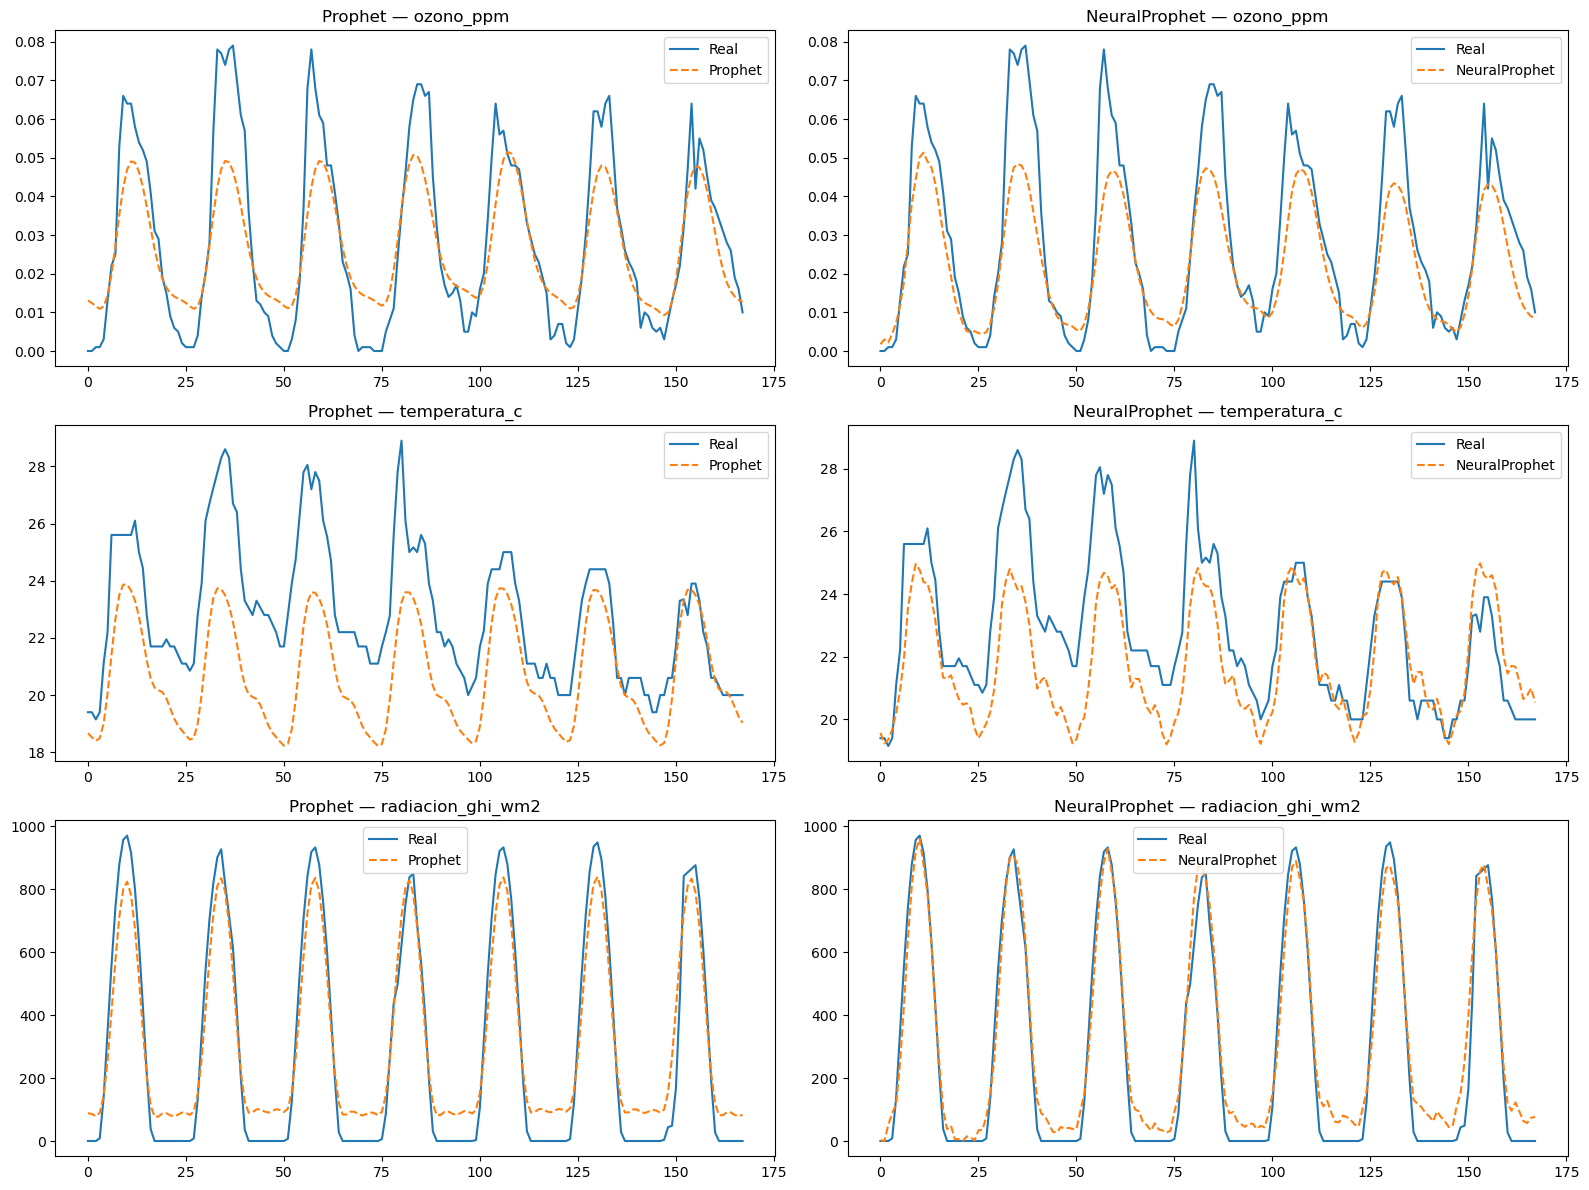

In [4]:
fig, axes = plt.subplots(len(datos.columns), 2, figsize=(16, 12))

for fila, col in enumerate(datos.columns):
    if col in resultados_prophet:
        axes[fila, 0].plot(resultados_prophet[col]["_test_real"], label="Real")
        axes[fila, 0].plot(resultados_prophet[col]["_test_pred"], label="Prophet", linestyle="--")
        axes[fila, 0].set_title(f"Prophet — {col}")
        axes[fila, 0].legend()
    else:
        axes[fila, 0].set_title(f"Prophet — {col} (no disponible, ver nota de la sección 1)")

    axes[fila, 1].plot(resultados_nprophet[col]["_test_real"], label="Real")
    axes[fila, 1].plot(resultados_nprophet[col]["_test_pred"], label="NeuralProphet", linestyle="--")
    axes[fila, 1].set_title(f"NeuralProphet — {col}")
    axes[fila, 1].legend()

plt.tight_layout()
plt.show()

## 4. Guardado de resultados

In [5]:
def limpiar(resultados):
    return {col: {"MAE": r["MAE"], "RMSE": r["RMSE"]} for col, r in resultados.items()}

(PROJECT_ROOT / "data/processed/resultados_prophet.json").write_text(
    json.dumps(limpiar(resultados_prophet), indent=2), encoding="utf-8"
)
(PROJECT_ROOT / "data/processed/resultados_neuralprophet.json").write_text(
    json.dumps(limpiar(resultados_nprophet), indent=2), encoding="utf-8"
)

print("Prophet:")
print(json.dumps(limpiar(resultados_prophet), indent=2))
print("\nNeuralProphet:")
print(json.dumps(limpiar(resultados_nprophet), indent=2))
print("\nProyecto listo para continuar con 10_darts.ipynb")

Prophet:
{
  "ozono_ppm": {
    "MAE": 0.008978780059912176,
    "RMSE": 0.011898728085099343
  },
  "temperatura_c": {
    "MAE": 2.172616412850747,
    "RMSE": 2.5588676691841643
  },
  "radiacion_ghi_wm2": {
    "MAE": 85.5081228338253,
    "RMSE": 92.35720638608714
  }
}

NeuralProphet:
{
  "ozono_ppm": {
    "MAE": 0.008643477676547176,
    "RMSE": 0.01215456563110382
  },
  "temperatura_c": {
    "MAE": 1.3821439847113604,
    "RMSE": 1.7697816564635056
  },
  "radiacion_ghi_wm2": {
    "MAE": 58.384077233969734,
    "RMSE": 69.81521074746138
  }
}

Proyecto listo para continuar con 10_darts.ipynb
